In [1]:
"""
The Goal of this notebook:
- initialize the target grid
- this means to generate multiple target areas


Verification:
-show all renders of the target grid
--big picture
--close up view
(static is okay)
--reward on camera detection must still work

API:
-inputs:
-- go through SimConfig (can be consumed by Sim Kernel)
-- define what is needed (keep running in sim kernel in mind, should tie in SimConfig, can be extended, can be passed as function)
-- (instead of passing target area, where target area is currently parsed send this function)

-output:
-- list[TargetArea]

use defaults:
-number 50
-10km length
-30km gap
-evenly spaced grid
-coloring in viz red
-
"""

'\nThe Goal of this notebook:\n- initialize the target grid\n- this means to generate multiple target areas\n\n\nVerification:\n-show all renders of the target grid\n--big picture\n--close up view\n(static is okay)\n--reward on camera detection must still work\n\nAPI:\n-inputs:\n-- go through SimConfig (can be consumed by Sim Kernel)\n-- define what is needed (keep running in sim kernel in mind, should tie in SimConfig, can be extended, can be passed as function)\n-- (instead of passing target area, where target area is currently parsed send this function)\n\n-output:\n-- list[TargetArea]\n\nuse defaults:\n-number 50\n-10km length\n-30km gap\n-evenly spaced grid\n-coloring in viz red\n-\n'

In [2]:
from __future__ import annotations

from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path
import json
import sys

import numpy as np
# Resolve project/backend roots from notebook location.
_cwd = Path.cwd().resolve()
_candidates = [_cwd, _cwd.parent, _cwd.parent.parent, _cwd.parent.parent.parent]
project_root = None
for p in _candidates:
    if (p / "backend").exists():
        project_root = p
        break
if project_root is None:
    raise RuntimeError("Could not resolve project root containing backend/.")

backend_root = project_root / "backend"
if str(backend_root) not in sys.path:
    sys.path.insert(0, str(backend_root))

In [3]:
from environment_definition.constants.MISSION import ObservationTargetArea, LON_GLOBAL
from utils.geodesics.geodesic_helpers import geodesic_distance, GeodeticBoundingBox
from pint import Quantity
from environment_definition.constants.UNIT_REGISTRY import UREG as ureg

In [4]:
from utils.geometry.polar_meridian_track import build_target_grid_polar_meridian

target_size = 15 * ureg.kilometer
spacing = 40 * ureg.kilometer
anchor_lat = 80 * ureg.deg
segments = build_target_grid_polar_meridian(
    anchor_lat=anchor_lat,
    anchor_lon=LON_GLOBAL,
    n_targets=50,
    target_size=target_size,
    spacing=spacing,
)
targets = [segment.to_observation_target_area() for segment in segments]
for target in targets:
    print(target)

ObservationTargetArea(lat_min=<Quantity(80.0, 'degree')>, lat_max=<Quantity(80.1348981, 'degree')>, label='target_0')
ObservationTargetArea(lat_min=<Quantity(80.4946262, 'degree')>, lat_max=<Quantity(80.6295243, 'degree')>, label='target_1')
ObservationTargetArea(lat_min=<Quantity(80.9892524, 'degree')>, lat_max=<Quantity(81.1241505, 'degree')>, label='target_2')
ObservationTargetArea(lat_min=<Quantity(81.4838786, 'degree')>, lat_max=<Quantity(81.6187767, 'degree')>, label='target_3')
ObservationTargetArea(lat_min=<Quantity(81.9785048, 'degree')>, lat_max=<Quantity(82.1134029, 'degree')>, label='target_4')
ObservationTargetArea(lat_min=<Quantity(82.473131, 'degree')>, lat_max=<Quantity(82.6080291, 'degree')>, label='target_5')
ObservationTargetArea(lat_min=<Quantity(82.9677572, 'degree')>, lat_max=<Quantity(83.1026553, 'degree')>, label='target_6')
ObservationTargetArea(lat_min=<Quantity(83.4623834, 'degree')>, lat_max=<Quantity(83.5972815, 'degree')>, label='target_7')
ObservationTarg

Target grid verification summary
  count:                50
  first label:          target_0
  last label:           target_49
  labels contiguous:    True
  monotonic offsets:    True
  any touches pole:     False
  any past pole:        True
  first band:           80.000000 deg -> 80.134898 deg
  last band:            75.628418 deg -> 75.763316 deg
  final track offset:   14.371582 deg

Structured target table
idx  label       lat_min_deg  lat_max_deg   track_km       gap_km         status
  0  target_0      80.000000    80.134898     15.000            -             OK
  1  target_1      80.494626    80.629524     15.000       40.000             OK
  2  target_2      80.989252    81.124150     15.000       40.000             OK
  3  target_3      81.483879    81.618777     15.000       40.000             OK
  4  target_4      81.978505    82.113403     15.000       40.000             OK
  5  target_5      82.473131    82.608029     15.000       40.000             OK
  6  target_6   

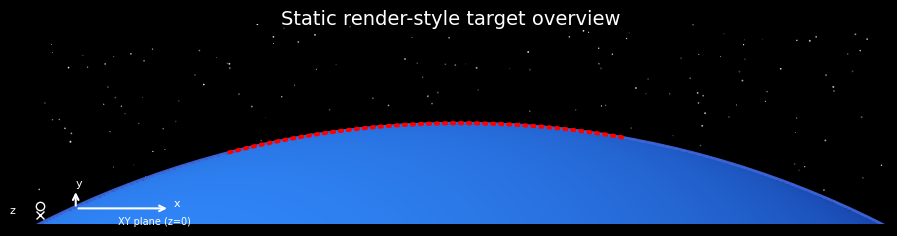

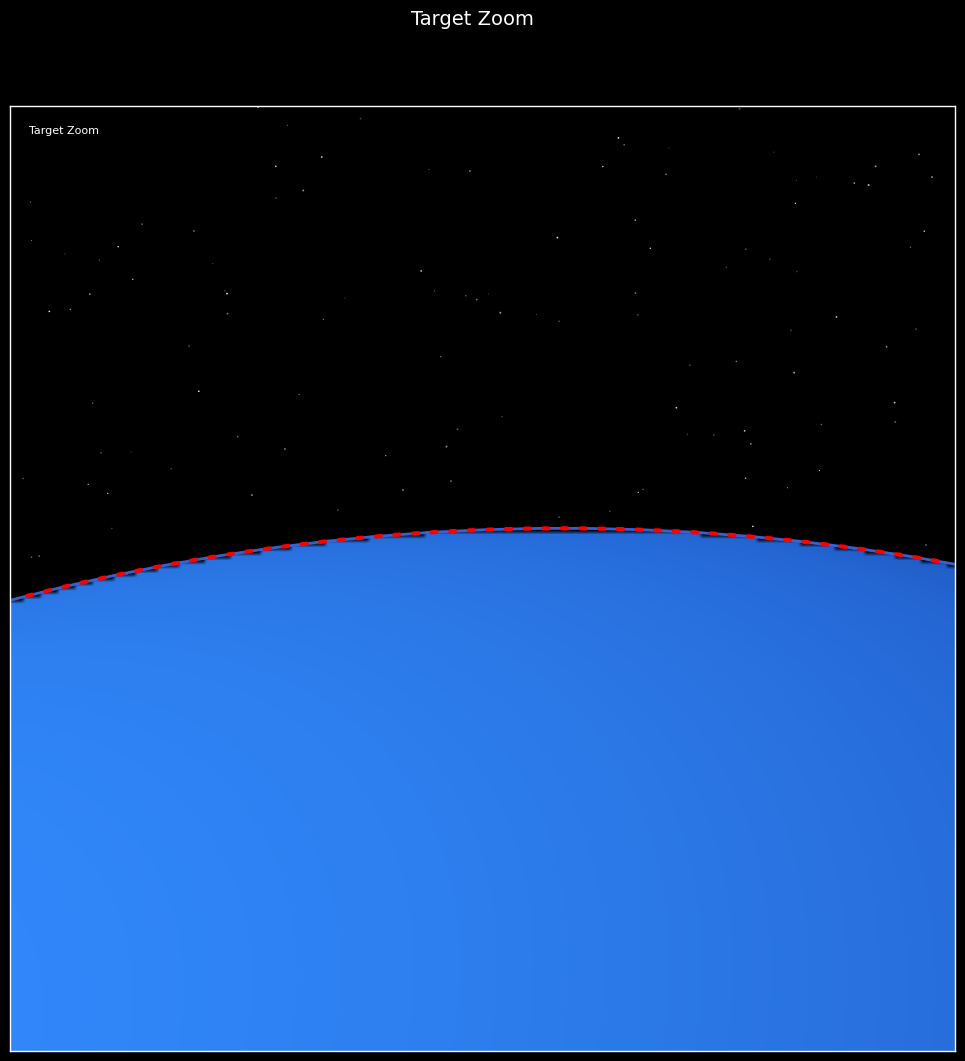

In [5]:
# Verification layer for notebook 01: target table + static render-style main/closeup views.
import matplotlib.pyplot as plt

from environment_definition.constants import EARTH_RADIUS, RENDER, SIMULATION
from environment_definition.constants.MISSION import los_theta_offsets_deg
from environment_definition.mission_profiles.s00_simulation_build_sample_fl import SATELLITE_ALTITUDE
from render._closeup_view import build_closeup_panel
from render._main_view import build_main_panel
from utils.geometry.mission_stripe_disk import geodetic_on_lon_meridian_to_disk_polar_deg

theta_center_deg = float(SIMULATION.theta_center.to("deg").magnitude)

rows: list[dict[str, float | int | str]] = []
labels_match = True
monotonic_track_offsets = True
any_touches_pole = False
any_past_pole = False
phi_bounds_deg: list[tuple[float, float]] = []

earth_radius_km = float(EARTH_RADIUS.to("km").magnitude)

for idx, (segment, target) in enumerate(zip(segments, targets)):
    lat_min_deg = float(target.lat_min.to("deg").magnitude)
    lat_max_deg = float(target.lat_max.to("deg").magnitude)
    lon_min_deg = segment.endpoint_lon_deg(which="min")
    lon_max_deg = segment.endpoint_lon_deg(which="max")
    labels_match = labels_match and (target.label == f"target_{idx}")

    if rows and segment.track_offset_lo_deg <= float(rows[-1]["track_offset_hi_deg"]):
        monotonic_track_offsets = False

    touches_pole = lat_min_deg <= 90.0 <= lat_max_deg
    past_pole = segment.track_offset_hi_deg > 0.0
    any_touches_pole = any_touches_pole or touches_pole
    any_past_pole = any_past_pole or past_pole

    track_span_deg = float(segment.track_offset_hi_deg - segment.track_offset_lo_deg)
    track_band_km = float(np.deg2rad(track_span_deg) * earth_radius_km)

    track_gap_km = float("nan")
    if idx > 0:
        prev_segment = segments[idx - 1]
        track_gap_deg = float(segment.track_offset_lo_deg - prev_segment.track_offset_hi_deg)
        track_gap_km = float(np.deg2rad(track_gap_deg) * earth_radius_km)

    phi_lo_deg, phi_hi_deg = segment.phi_bounds_deg(theta_center_deg=theta_center_deg)
    phi_bounds_deg.append((phi_lo_deg, phi_hi_deg))

    status = "OK"
    if touches_pole:
        status = "touches_pole"
    if past_pole:
        status = "past_pole"

    rows.append(
        {
            "idx": idx,
            "label": target.label,
            "lat_min_deg": lat_min_deg,
            "lat_max_deg": lat_max_deg,
            "lon_min_deg": lon_min_deg,
            "lon_max_deg": lon_max_deg,
            "track_offset_lo_deg": segment.track_offset_lo_deg,
            "track_offset_hi_deg": segment.track_offset_hi_deg,
            "track_band_km": track_band_km,
            "track_gap_km": track_gap_km,
            "status": status,
        }
    )

print("Target grid verification summary")
print(f"  count:                {len(rows)}")
print(f"  first label:          {rows[0]['label']}")
print(f"  last label:           {rows[-1]['label']}")
print(f"  labels contiguous:    {labels_match}")
print(f"  monotonic offsets:    {monotonic_track_offsets}")
print(f"  any touches pole:     {any_touches_pole}")
print(f"  any past pole:        {any_past_pole}")
print(f"  first band:           {rows[0]['lat_min_deg']:.6f} deg -> {rows[0]['lat_max_deg']:.6f} deg")
print(f"  last band:            {rows[-1]['lat_min_deg']:.6f} deg -> {rows[-1]['lat_max_deg']:.6f} deg")
print(f"  final track offset:   {rows[-1]['track_offset_hi_deg']:.6f} deg")

print("\nStructured target table")
print(
    f"{'idx':>3}  {'label':<10} {'lat_min':>9} {'lat_max':>9} "
    f"{'lon_min':>8} {'lon_max':>8} {'track_km':>9} {'gap_km':>9} {'status':>14}"
)
for row in rows:
    gap_text = "-" if row["idx"] == 0 else f"{float(row['track_gap_km']):.3f}"
    print(
        f"{int(row['idx']):>3}  {str(row['label']):<10} "
        f"{float(row['lat_min_deg']):>9.3f} {float(row['lat_max_deg']):>9.3f} "
        f"{float(row['lon_min_deg']):>8.1f} {float(row['lon_max_deg']):>8.1f} "
        f"{float(row['track_band_km']):>9.3f} {gap_text:>9} {str(row['status']):>14}"
    )

r_earth_km = float(EARTH_RADIUS.to("km").magnitude)
r_orbit_km = r_earth_km + float(SATELLITE_ALTITUDE.to("km").magnitude)
theta_center_rad = float(SIMULATION.theta_center.to("rad").magnitude)
theta_center_deg = float(SIMULATION.theta_center.to("deg").magnitude)
margin_deg = float(SIMULATION.contact_margin_angle.to("deg").magnitude)
los_lo_deg, los_hi_deg = los_theta_offsets_deg(
    orbit_height=SATELLITE_ALTITUDE,
    margin_deg=margin_deg,
)

overall_phi_lo_deg = min(lo for lo, _ in phi_bounds_deg)
overall_phi_hi_deg = max(hi for _, hi in phi_bounds_deg)
frame_lo_deg = min(los_lo_deg, los_hi_deg, overall_phi_lo_deg - theta_center_deg, overall_phi_hi_deg - theta_center_deg)
frame_hi_deg = max(los_lo_deg, los_hi_deg, overall_phi_lo_deg - theta_center_deg, overall_phi_hi_deg - theta_center_deg)

mid_lat_deg = 0.5 * (
    float(targets[0].lat_min.to("deg").magnitude) + float(targets[-1].lat_max.to("deg").magnitude)
)
view_anchor_phi_deg = geodetic_on_lon_meridian_to_disk_polar_deg(
    lat_deg=mid_lat_deg,
    lon_deg=float(LON_GLOBAL.to("deg").magnitude),
)
view_anchor_x = r_earth_km * np.cos(np.deg2rad(view_anchor_phi_deg))
view_anchor_y = r_earth_km * np.sin(np.deg2rad(view_anchor_phi_deg))

scene = {
    "R_earth": r_earth_km,
    "R_orbit": r_orbit_km,
    "theta_center": theta_center_rad,
    "start_angle_deg": frame_lo_deg,
    "end_angle_deg": frame_hi_deg,
    "target_region_start_angle_deg": overall_phi_lo_deg,
    "target_region_end_angle_deg": overall_phi_hi_deg,
    "target_region_bounds_deg": phi_bounds_deg,
    "view_anchor_x": float(view_anchor_x),
    "view_anchor_y": float(view_anchor_y),
    "view_anchor_pos": np.asarray([view_anchor_x, view_anchor_y], dtype=float),
    "cloud_models": [],
    "n_clouds": 0,
    "n_bins": 0,
    "n_bins_secondary": 0,
    "controller_mode": "static-target-grid",
}

_debug_log_path = project_root / "debug-78ee2f.log"


def _fit_standalone_axes(
    ax,
    fig: plt.Figure,
    *,
    margin_l: float = 0.06,
    margin_b: float = 0.10,
    margin_w: float = 0.9,
    title_frac: float = 0.08,
) -> None:
    """Match figure height to equal-aspect data so adjustable='box' does not shrink the axes."""
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    data_aspect = (xlim[1] - xlim[0]) / (ylim[1] - ylim[0])
    usable_h_frac = 1.0 - margin_b - title_frac
    fig_w, _ = fig.get_size_inches()
    fig_h = (margin_w * fig_w) / data_aspect / usable_h_frac
    fig.set_size_inches(fig_w, fig_h)
    fig_w, fig_h = fig.get_size_inches()
    h_frac = (margin_w * fig_w) / data_aspect / fig_h
    ax.set_position([margin_l, margin_b, margin_w, h_frac])
    ax.set_aspect("equal", adjustable="box")


fig_main = plt.figure(figsize=(9.5, 6.5), facecolor=RENDER.space_background)
axes_main, _artists_main = build_main_panel(fig_main, scene)
_fit_standalone_axes(axes_main["main"], fig_main)
#region agent log
import time as _time

with _debug_log_path.open("a", encoding="utf-8") as _f:
    _f.write(
        json.dumps(
            {
                "sessionId": "78ee2f",
                "runId": "notebook",
                "hypothesisId": "G",
                "location": "01-target_grid.ipynb:main_frame",
                "message": "main axes after aspect fit",
                "data": {
                    "position": list(axes_main["main"].get_position().bounds),
                    "figsize_in": list(fig_main.get_size_inches()),
                },
                "timestamp": int(_time.time() * 1000),
            }
        )
        + "\n"
    )
#endregion
fig_main.suptitle("Static render-style target overview", color="white", fontsize=14)
plt.show()

fig_closeup = plt.figure(figsize=(10.5, 4.8), facecolor=RENDER.space_background)
axes_closeup, _artists_closeup = build_closeup_panel(fig_closeup, scene)
_fit_standalone_axes(axes_closeup["closeup"], fig_closeup, margin_b=0.12, title_frac=0.10)
fig_closeup.suptitle("Target Zoom", color="white", fontsize=14)
plt.show()

In [6]:
# Coast rollout + export video: canonical sim → SimulationStateSeries → render export.
from dataclasses import replace

import matplotlib

matplotlib.use("Agg")

import numpy as np

from environment_definition.constants.SIMULATION import OBSERVATION_TARGET, RenderMode, SimulationConfig
from environment_definition.mission_profiles.s01_multiple_targets_fwd_fish import build_setup
from simulation.run_simulation import run_simulation
from utils.notebook.video import export_and_play_saved_video

ARTIFACT_DIR = backend_root / "notebooks" / "s01" / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

setup = replace(
    build_setup(seed=0, include_cameras=True),
    target_areas=tuple(targets),
    clouds=(),
)

sim_cfg = SimulationConfig(render_mode=RenderMode.HEADLESS, controller_mode="coast")
print("Running coast episode with polar-meridian target grid…")
grid_series = run_simulation(setup=setup, simulation_config=sim_cfg)

n_target_hits = int(np.sum(grid_series.camera_observation_line_codes == np.int8(OBSERVATION_TARGET)))
print(f"  frames: {len(grid_series.t_s)}")
print(f"  target ray hits (all bins): {n_target_hits}")
print(f"  mean reward: {float(np.mean(grid_series.simulation_reward)):.3f}")
print(f"  render bands in metadata: {len(grid_series.metadata.target_region_bounds_deg or ())}")

video_path = ARTIFACT_DIR / "target_grid_coast.mp4"
export_and_play_saved_video(simulation_series=grid_series, out_path=video_path)
print(f"Saved: {video_path}")



D:\code\sem-proj-asc\backend\simulation\stepper.py:149: UserWarning: controller_update_interval is not an integer multiple of simulation_timestep; using nearest multiple.
  self._controller_interval_steps, self._effective_controller_interval_s = resolve_controller_interval_steps(


Running coast episode with polar-meridian target grid…


Running simulation: 100%|██████████| 1923/1923 [00:52<00:00, 36.89step/s]


  frames: 1924
  target ray hits (all bins): 40410
  mean reward: -51.639
  render bands in metadata: 50
[mpo_video:after_export] target_grid_coast.mp4 (12409027 bytes)
Saved: D:\code\sem-proj-asc\backend\notebooks\s01\artifacts\target_grid_coast.mp4
[mpo_video:play] target_grid_coast.mp4 (12409027 bytes)
